In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/data/spanish_project/pn_ps_dn_ds_logistic_regression/pn_ps_simple/statistics_per_gene_polymorphism_g3_g10_filter_low_pvt_var_10_wald0.4184490972257678_gee.tsv",sep="\t")

In [3]:
df

,gene,OR,coeff,pvalues,bse,wald_p
0,AA1G01010,1.838710,0.609064,0.021829,0.265581,0.472926
1,AA1G01050,3.038961,1.111516,0.028826,0.508502,0.172896
2,AA1G01080,1.500000,0.405465,0.439409,0.524404,0.980247
3,AA1G01110,0.222222,-1.504077,0.025626,0.673919,0.004334
4,AA1G01160,0.620301,-0.477551,0.350495,0.511499,0.079823
...,...,...,...,...,...,...
10917,AA8G55180,3.342857,1.206826,0.062892,0.648846,0.224349
10918,AA8G55210,0.601504,-0.508322,0.244523,0.436795,0.033858
10919,AA8G55220,0.523810,-0.646627,0.240132,0.550482,0.053014
10920,AA8G55280,3.000000,1.098612,0.159917,0.781736,0.384263


In [4]:
import gffpandas.gffpandas as gffpd

In [5]:
annotation = gffpd.read_gff3("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/annotation/Arabis_alpina_mpipz_v5.1_annotation.gff")


In [6]:
combined_df = annotation.filter_feature_of_type(['gene'])
genes_df=combined_df.attributes_to_columns()

In [7]:
genes_df.columns=['seq_id', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase',
       'attributes', 'Alias', 'Dbxref', 'ID', 'gene', 'Note', 'Ontology_term',
       'date_creation', 'date_last_modified', 'description', 'owner']

In [8]:
stats=df

In [9]:
genes_data=pd.merge(stats,genes_df, on="gene")


In [10]:
mask=pd.read_csv("I:/dep_coupland/grp_fulgione/common/1000Genomes/ParaMask_SNPable_combined_masks/ParaMask_Cantabria_and_French_30PerMiss_v3_EM2.7.1_EMresults.chrall.finalClass.multicopy.ZeroBasedStart.SNPable.3col.sorted.merged.bed", sep="\t", header=None)
mask.columns=["chr","start","end"]

In [11]:
def region_in_mask(chrom, start_r, end_r, mask):
    mask_chr=mask[mask["chr"]==chrom]
    mask_chr_s=mask_chr[(mask_chr["start"]<start_r) & (mask_chr["end"]>start_r)]
    mask_chr_e=mask_chr[(mask_chr["start"]<end_r) & (mask_chr["end"]>end_r)]
    mask_chr_1=mask_chr[(mask_chr["start"]>start_r) & (mask_chr["end"]<end_r)]
    mask_chr_2=mask_chr[(mask_chr["start"]<start_r) & (mask_chr["end"]>end_r)]
    if len(mask_chr_s)==0 and len(mask_chr_e)==0 and len(mask_chr_1)==0 and len(mask_chr_2)==0:
        return("no")
    else:
        return ("yes")

In [12]:
multi_copy_regions=[]
for i in genes_data.index:
    multi_copy_regions.append(region_in_mask(genes_data["seq_id"][i],int(genes_data["start"][i]),int(genes_data["end"][i]),mask))

In [13]:
genes_data["multi_copy"]=multi_copy_regions
genes_data_mutli=genes_data[genes_data["multi_copy"]=="no"]

In [14]:
genes_data_mutli=genes_data_mutli[["gene","OR","coeff","pvalues","bse","wald_p"]]


In [15]:
paramask=list(genes_data_mutli["gene"])

In [16]:
import numpy as np

In [17]:
np.log(genes_data_mutli["OR"].mean())

0.4184490972257678

<Axes: xlabel='coeff', ylabel='Count'>

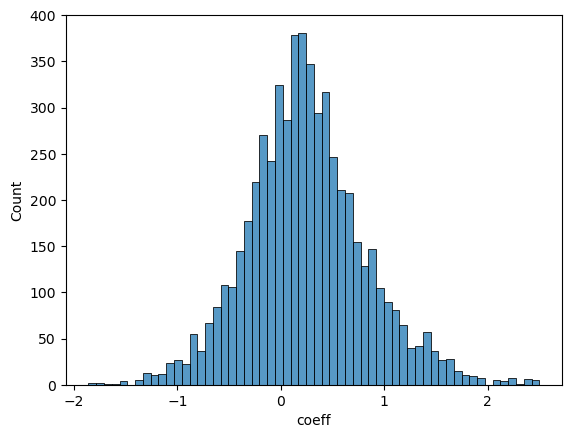

In [18]:
sns.histplot(genes_data_mutli["coeff"])


In [22]:
genes_data_mutli

,gene,OR,coeff,pvalues,bse
2,AA1G01080,1.500000,0.405465,0.439409,0.524404
3,AA1G01110,0.222222,-1.504077,0.025626,0.673919
5,AA1G01190,0.642857,-0.441833,0.366164,0.488925
6,AA1G01220,1.466667,0.382992,0.411601,0.466450
8,AA1G01240,3.061224,1.118815,0.023190,0.492805
...,...,...,...,...,...
10916,AA8G55170,1.895833,0.639658,0.314694,0.636209
10917,AA8G55180,3.342857,1.206826,0.062892,0.648846
10918,AA8G55210,0.601504,-0.508322,0.244523,0.436795
10919,AA8G55220,0.523810,-0.646627,0.240132,0.550482


<Axes: xlabel='wald_p', ylabel='Count'>

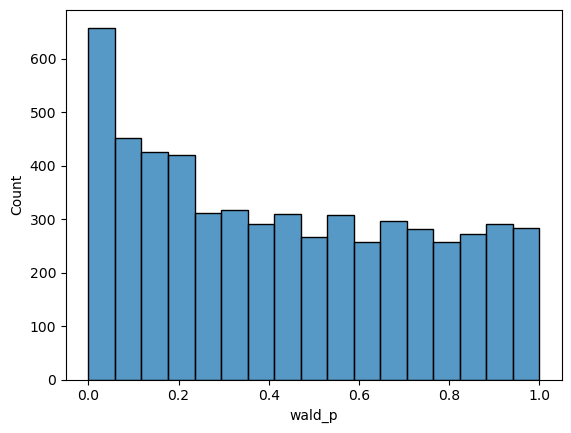

In [26]:
sns.histplot(genes_data_mutli["wald_p"])


In [27]:
import statsmodels.stats.multitest


In [28]:
genes_data_mutli["multi_pvalue_wald"]=statsmodels.stats.multitest.multipletests(genes_data_mutli["wald_p"], alpha=0.05, method='fdr_bh', maxiter=1, is_sorted=False, returnsorted=False)[1]


In [29]:
genes_data_mutli[genes_data_mutli["multi_pvalue_wald"]<=0.05]

,gene,OR,coeff,pvalues,bse,wald_p,multi_pvalue_wald
619,AA1G15460,1.028302,0.027909,0.724752,0.079261,8.337426e-07,0.004747
4005,AA4G03560,0.521739,-0.650588,0.005376,0.233723,4.786293e-06,0.009084
5733,AA5G10450,0.779626,-0.248941,0.083428,0.143802,3.466894e-06,0.009084


In [30]:
genes_data_mutli[genes_data_mutli["multi_pvalue_wald"]<=0.06]

,gene,OR,coeff,pvalues,bse,wald_p,multi_pvalue_wald
133,AA1G03720,0.511111,-0.671168,0.010937,0.263752,3.608487e-05,0.051367
619,AA1G15460,1.028302,0.027909,0.724752,0.079261,8.337426e-07,0.004747
4005,AA4G03560,0.521739,-0.650588,0.005376,0.233723,4.786293e-06,0.009084
5733,AA5G10450,0.779626,-0.248941,0.083428,0.143802,3.466894e-06,0.009084
